In [1]:
# coverage env
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# variables

In [2]:
chrX='CM019819.2'

# scripts

In [3]:
def all_spaghettis(coverage_df, sample, chr_of_interest=chrX, with_plots=True):
    pos = coverage_df['position'].to_numpy()
    cov = coverage_df['coverage'].to_numpy()

    cumsum_cov = np.cumsum(cov)

    demeaned    = cov - cov.mean()
    cs_signal   = np.cumsum(demeaned)
    linear_line = np.linspace(cs_signal[0], cs_signal[-1], len(cs_signal))
    deviation   = cs_signal - linear_line
    change_idx  = np.argmax(np.abs(deviation))
    change_pos  = pos[change_idx]

    print(f"Change point: {change_pos}")

    if with_plots:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

        ax1.plot(pos, cumsum_cov, label='Cumsum', color="#4878d0")
        # ax1.set_title(f"{sample}; {chr_of_interest}; Cumulative coverage")
        ax1.set_xlabel("Genomic position, bp")
        ax1.set_ylabel("Cumulative coverage")
        # ax1.grid(True)
        ax1.legend(loc='best')

        ax2.plot(cs_signal, label='Normalised cumsum', color="#4878d0")
        ax2.plot(linear_line, '--', label='Linear fit', color="#82c6e2")
        ax2.axvline(change_idx, color='#d65f5f', ls='--',
                    label=f'Pos: {change_pos}')
        # ax2.set_title(f"{sample}; {chr_of_interest}; Cumulative sum with change point")
        ax2.set_xlabel('Genomic position, bp')
        ax2.set_ylabel('Cumulative signal')
        ax2.legend(loc='best')
        
        plt.tight_layout()
        plt.show()

In [4]:
def read_coverage_file(file, header=None):
    columns = ['chrom', 'position', 'coverage']
    df = pd.read_csv(file, sep='\t', header=header, usecols=[0, 2, 3], names=columns, compression='gzip')
    return df

# analysis

Change point: 122645400


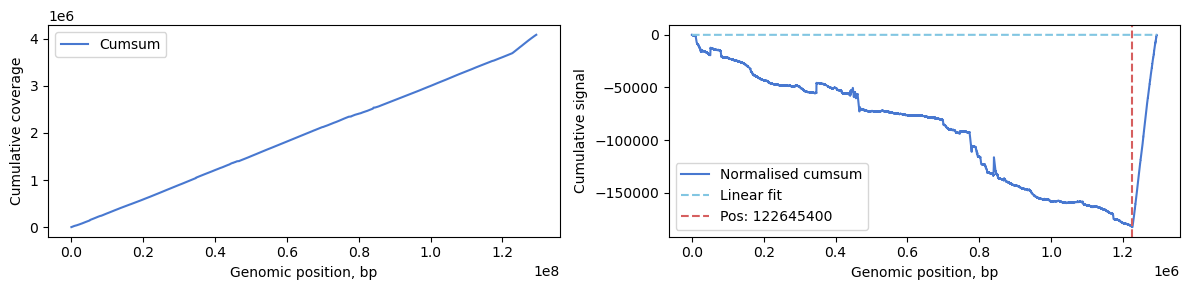

In [ ]:
basepath=""
file=f"{basepath}/Coverage/GSL_CM019819.2_win100/FH01.REA.MD.CM019819.2.Q20.F3844.bam.win100.mean.regions.bed.gz"
sample="FH01"
coverage_df=read_coverage_file(file)
all_spaghettis(coverage_df, sample)